### Load Library

In [65]:
import pandas as pd
import requests
import os
import re

### Function: fetch_kegg_amr_database

In [2]:
def fetch_kegg_amr_database():
    # Downloads and parses the official Antimicrobial Resistance KO IDs from KEGG.

    print("Fetching official ARG database from KEGG (ko01504)...")
    kegg_url = "http://rest.kegg.jp/link/ko/br:ko01504"
    
    db_dir = "data/database"
    os.makedirs(db_dir, exist_ok=True)
    
    kegg_file = "data/database/kegg_amr_ko01504.txt"
    
    # Download if we don't have it yet
    if not os.path.exists(kegg_file):
        print(f"Downloading KEGG database to {kegg_file}...")
        response = requests.get(kegg_url)
        if response.status_code == 200:
            with open(kegg_file, 'w') as f:
                f.write(response.text)
        else:
            print("Failed to download KEGG database.")
            return set()
    else:
        print(f"Using local cached KEGG database at {kegg_file}.")

    amr_ko_set = set()
    try:
        with open(kegg_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split('\t') # Format is usually 'br:ko01504 \t ko:K00059'
                    if len(parts) > 1:
                        ko_id = parts[1].replace('ko:', '')
                        amr_ko_set.add(ko_id)
        print(f"Successfully loaded {len(amr_ko_set)} official Antibiotic Resistance KOs.")
    except Exception as e:
        print(f"Error reading local KEGG database: {e}")
        
    return amr_ko_set


### Function: fetch_bacmet_database

In [3]:
def fetch_bacmet_database():
    # Downloads and parses the BacMet experimentally confirmed biocide/metal resistance database mapping file.
    print("Fetching official BRG database from BacMet...")
    bacmet_url = "http://bacmet.biomedicine.gu.se/download/BacMet2_EXP.753.mapping.txt"
    bacmet_file = "data/database/BacMet2_EXP.753.mapping.txt"
    
    # Download if we don't have it yet
    if not os.path.exists(bacmet_file):
        response = requests.get(bacmet_url)
        if response.status_code == 200:
            with open(bacmet_file, 'w') as f:
                f.write(response.text)
        else:
            print("Failed to download BacMet database.")
            return set()

    bacmet_genes = set()
    try:
        bacmet_df = pd.read_csv(bacmet_file, sep='\t')

        # print(bacmet_df.columns)
        genes = bacmet_df['Gene_name'].dropna().astype(str).str.lower().tolist()

        all_genes = []
        for g in genes:
            all_genes.append(g)
            if '/' in g:
                all_genes.extend([x.strip() for x in g.split('/')])
        
        bacmet_genes = set(all_genes)
        print(f"Successfully loaded {len(bacmet_genes)} official Biocide/Metal Resistance Genes.")
    except Exception as e:
        print(f"Error parsing BacMet: {e}")
        
    return bacmet_genes


### Load Data

In [67]:
master_df = pd.read_csv("data/master_functional_matrix.tsv", sep='\t')
master_df.shape
# master_df.head()

(62195, 12)

### Find AMR & BRG

In [66]:
amr_ko_set = fetch_kegg_amr_database()
bacmet_genes = fetch_bacmet_database()

Fetching official ARG database from KEGG (ko01504)...
Using local cached KEGG database at data/database/kegg_amr_ko01504.txt.
Successfully loaded 237 official Antibiotic Resistance KOs.
Fetching official BRG database from BacMet...
Successfully loaded 758 official Biocide/Metal Resistance Genes.


In [68]:
master_df['KO_function_lower'] = master_df['KO_function'].fillna('').str.lower()

def matches_bacmet(function_text):
    words = set(re.findall(r'\b[a-z0-9]+\b', function_text))
    return not words.isdisjoint(bacmet_genes)
    
master_df['is_BRG'] = master_df['KO_function_lower'].apply(matches_bacmet)
master_df['is_AMR'] = master_df['KO_ID'].isin(amr_ko_set)

print(master_df.shape)
# master_df.head()

(62195, 15)


In [80]:
print(master_df['is_BRG'].value_counts(), '\n')
print(master_df['is_AMR'].value_counts(), '\n')
# print(master_df['Sample_ID'].unique(), '\n')
print(master_df['Sample_Category'].value_counts(), '\n')

is_BRG
False    61291
True       904
Name: count, dtype: int64 

is_AMR
False    61686
True       509
Name: count, dtype: int64 

Sample_Category
Environmental    56261
Control           5934
Name: count, dtype: int64 



### Identify AMR

In [70]:
amr_resistance_df = master_df[master_df['is_AMR']]
print(f"Number of genes with AMR: {len(amr_resistance_df)}")
# amr_resistance_df.head()

Number of genes with AMR: 509


In [73]:
# print(amr_resistance_df.shape)
# print(amr_resistance_df.columns)
# print(amr_resistance_df['Sample_ID'].unique())

# print(amr_resistance_df['genus'].value_counts(), '\n')
# print(amr_resistance_df['species'].value_counts(), '\n')

# print(amr_resistance_df['KO_function'].value_counts(), '\n')

# print(amr_resistance_df['Location'].value_counts(), '\n')

# print(amr_resistance_df['Sample_Type'].value_counts(), '\n')

# print(amr_resistance_df['Sample_Category'].value_counts(), '\n')

In [74]:
print(amr_resistance_df.loc[amr_resistance_df["Sample_Category"] == "Control", "Location"].value_counts(), '\n')
print(amr_resistance_df.loc[amr_resistance_df["Sample_Category"] == "Control", "genus"].value_counts(), '\n')

# ==============================================================================
# POSITIVE CONTROL VALIDATION SUMMARY
# 
# What this output means:
# 1. 'Location' Output: Our pipeline detected a total of 62 Antimicrobial 
#    Resistance (AMR) genes inside the "Zymo mock communities" (34 in Even, 
#    28 in Log). Zymo is a commercial standard tube of known DNA used as a 
#    positive control to ensure the sequencing worked.
#
# 2. 'Genus' Output: Out of those 62 AMR genes, 10 were successfully traced 
#    down to specific known bacteria (Listeria, Pseudomonas, Salmonella, and 
#    Limosilactobacillus) which are intentionally included in Zymo controls.
#    (The remaining 52 genes were detected but could not be confidently 
#    classified all the way down to the genus level, which is normal).
#
# Conclusion: This proves our bioinformatics pipeline (assembly, functional 
# annotation, and taxonomic classification) worked perfectly on known DNA.
# ==============================================================================


Location
Even distributed Zymo mock community DNA    34
Log distributed Zymo mock community DNA     28
Name: count, dtype: int64 

genus
Listeria               6
Pseudomonas            2
Salmonella             1
Limosilactobacillus    1
Name: count, dtype: int64 



In [75]:
# Remove the positive control samples from the cleanroom environmental AMR gene analysis.

env_amr_df = amr_resistance_df[amr_resistance_df["Sample_Category"] != "Control"].copy()
print(f"Cleanroom environmental AMR genes: {len(env_amr_df)} \n")

# print(env_amr_df['Sample_ID'].unique())
# print(env_amr_df['Sample_Category'].value_counts(), '\n')

env_amr_df.to_csv("data/env_amr_df.tsv", sep='\t', index=False)

Cleanroom environmental AMR genes: 447 



In [76]:
# Sum the normalized AMR load by physical location
location_burden = env_amr_df.groupby('Location')['CPM'].sum().sort_values(ascending=False)
print("--- Total AMR Burden by Location (CPM) ---")
print(location_burden)

--- Total AMR Burden by Location (CPM) ---
Location
Floor by cabinets          1211.656872
Floor by gowning room      1066.471554
Floor by airlock            914.770771
Floor mid room              679.618862
Floor by main door          637.584252
Floor by emergency exit     387.405384
Floor by spacecraft          43.783614
Tabletop                      7.378649
Name: CPM, dtype: float64


In [77]:
# Sum the normalized AMR load by bacterial genus
genus_burden = env_amr_df.groupby('genus')['CPM'].sum().sort_values(ascending=False)
print("--- AMR Carriers by Genus (CPM) ---")
print(genus_burden)

--- AMR Carriers by Genus (CPM) ---
genus
Acinetobacter       863.095105
Brevundimonas       424.526555
Paracoccus          407.768907
Stenotrophomonas    176.417315
Luteimonas           31.963770
Aspergillus          20.165938
Gemmobacter          17.601698
Sphingomonas         16.795439
Afipia               12.515709
Pseudomonas          11.720074
Rickettsia            5.236444
Corynebacterium       1.390289
Gilliamella           1.327658
Name: CPM, dtype: float64


In [78]:
org_amr = env_amr_df[env_amr_df['genus'] == 'Acinetobacter']
aci_mechanisms = org_amr['KO_function'].value_counts()
print("--- Resistance Mechanisms in Acinetobacter ---")
print(aci_mechanisms)

--- Resistance Mechanisms in Acinetobacter ---
KO_function
streptothricin acetyltransferase [EC:2.3.-.-]                                         22
outer membrane protein                                                                 9
TetR/AcrR family transcriptional regulator, mexJK operon transcriptional repressor     9
chloramphenicol O-acetyltransferase type B [EC:2.3.1.28]                               8
aminocyclitol acetyltransferase [EC:2.3.-.-]                                           7
membrane fusion protein, multidrug efflux system                                       2
aminoglycoside 3'-phosphotransferase III [EC:2.7.1.95]                                 2
dihydrofolate reductase (trimethoprim resistance protein) [EC:1.5.1.3]                 1
dihydropteroate synthase type 3 [EC:2.5.1.15]                                          1
Name: count, dtype: int64


In [59]:
org_amr = env_amr_df[env_amr_df['genus'] == 'Brevundimonas']
org_mechanisms = org_amr['KO_function'].value_counts()
print("--- Resistance Mechanisms in Brevundimonas ---")
print(org_mechanisms)

--- Resistance Mechanisms in Brevundimonas ---
KO_function
streptothricin acetyltransferase [EC:2.3.-.-]                                    8
fluoroquinolone resistance protein                                               7
BlaI family transcriptional regulator, penicillinase repressor                   6
two-component system, OmpR family, sensor histidine kinase PhoQ [EC:2.7.13.3]    5
MerR family transcriptional regulator, copper efflux regulator                   4
membrane fusion protein, multidrug efflux system                                 4
outer membrane protein                                                           3
beta-lactamase class A [EC:3.5.2.6]                                              3
chloramphenicol O-acetyltransferase type B [EC:2.3.1.28]                         3
zinc D-Ala-D-Ala carboxypeptidase [EC:3.4.17.14]                                 3
multidrug efflux pump                                                            3
phosphatidylglycerol lysyltr

In [60]:
org_amr = env_amr_df[env_amr_df['genus'] == 'Paracoccus']
org_mechanisms = org_amr['KO_function'].value_counts()
print("--- Resistance Mechanisms in Paracoccus ---")
print(org_mechanisms)

--- Resistance Mechanisms in Paracoccus ---
KO_function
aminocyclitol acetyltransferase [EC:2.3.-.-]                                     12
streptothricin acetyltransferase [EC:2.3.-.-]                                    12
membrane fusion protein, multidrug efflux system                                 10
multidrug efflux pump                                                            10
aminoglycoside 6'-N-acetyltransferase [EC:2.3.1.82]                               6
two-component system, OmpR family, sensor histidine kinase PhoQ [EC:2.7.13.3]     5
outer membrane protein                                                            4
MerR family transcriptional regulator, copper efflux regulator                    2
dihydropteroate synthase type 3 [EC:2.5.1.15]                                     1
Name: count, dtype: int64


### Graph

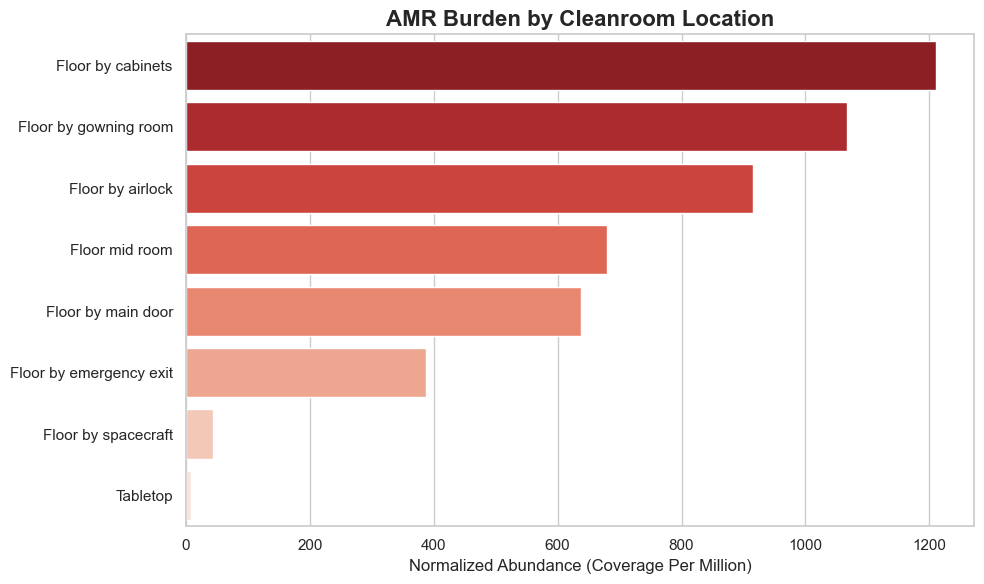

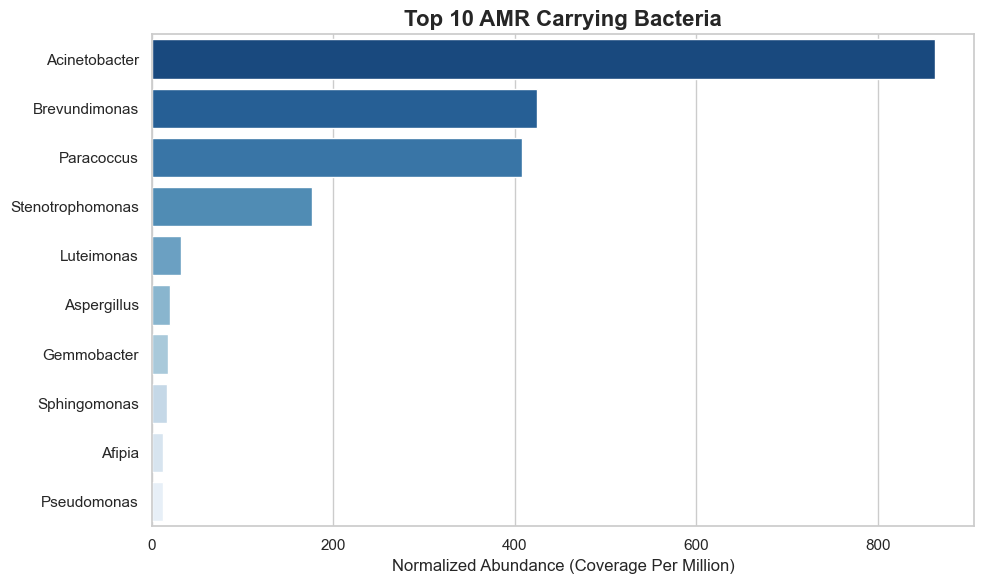

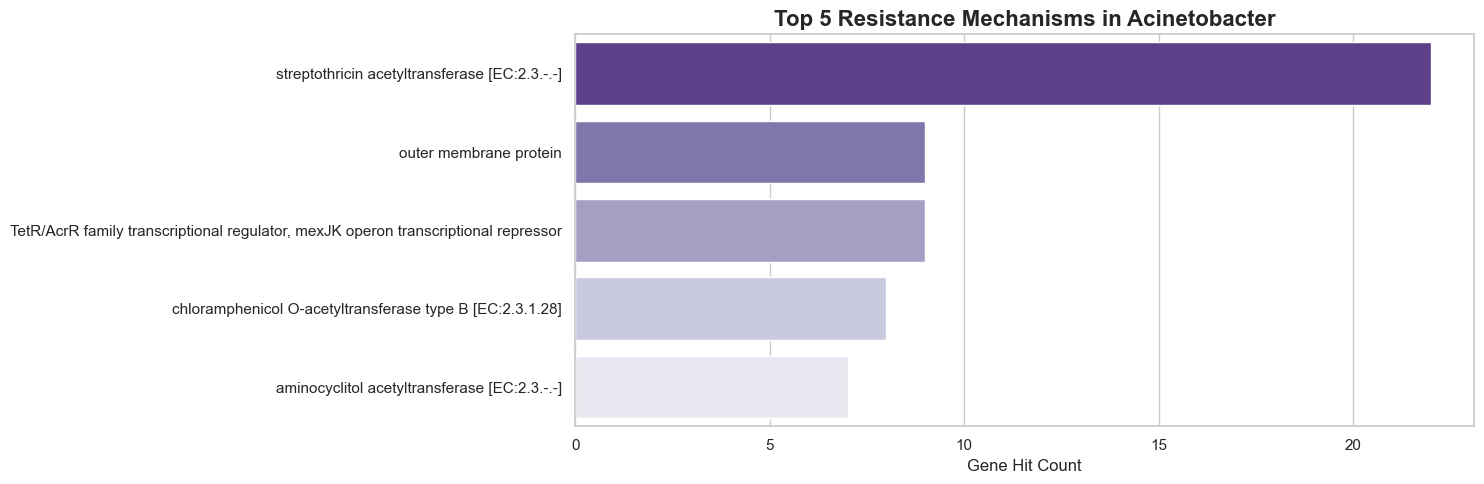

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "data/result"
os.makedirs(output_dir, exist_ok=True)

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# --- Figure 1: AMR Burden by Location ---
plt.figure(figsize=(10, 6))
sns.barplot(x=location_burden.values, y=location_burden.index, hue=location_burden.index, palette="Reds_r", legend=False)
plt.title("AMR Burden by Cleanroom Location", fontsize=16, fontweight='bold')
plt.xlabel("Normalized Abundance (Coverage Per Million)", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "amr_by_location.png"), dpi=300)
plt.show()

# --- Figure 2: Top 10 AMR Carriers ---
plt.figure(figsize=(10, 6))
sns.barplot(x=genus_burden.head(10).values, y=genus_burden.head(10).index, hue=genus_burden.head(10).index, palette="Blues_r", legend=False)
plt.title("Top 10 AMR Carrying Bacteria", fontsize=16, fontweight='bold')
plt.xlabel("Normalized Abundance (Coverage Per Million)", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "amr_by_genus.png"), dpi=300)
plt.show()

# --- Figure 3: Acinetobacter Mechanisms ---
# Take the top 5 mechanisms for a cleaner chart
top_aci = aci_mechanisms.head(5)

plt.figure(figsize=(15, 5))
sns.barplot(x=top_aci.values, y=top_aci.index, hue=top_aci.index, palette="Purples_r", legend=False)
plt.title("Top 5 Resistance Mechanisms in Acinetobacter", fontsize=16, fontweight='bold')
plt.xlabel("Gene Hit Count", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "acinetobacter_mechanisms.png"), dpi=300)
plt.show()

### Identify Dual Resistance

In [79]:
dual_resistance_df = env_amr_df[env_amr_df['is_BRG'] & env_amr_df['is_AMR']]
print(f"Number of genes with both BRG and AMR: {len(dual_resistance_df)}")

# display(dual_resistance_df.head())

print(dual_resistance_df['genus'].value_counts(), '\n')
print(dual_resistance_df['species'].value_counts(), '\n')

print(dual_resistance_df['KO_function'].value_counts(), '\n')

print(dual_resistance_df['Sample_Type'].value_counts(), '\n')

Number of genes with both BRG and AMR: 64
genus
Acinetobacter       9
Brevundimonas       4
Paracoccus          2
Stenotrophomonas    1
Name: count, dtype: int64 

species
Paracoccus haematequi    2
Name: count, dtype: int64 

KO_function
MerR family transcriptional regulator, copper efflux regulator                                    24
TetR/AcrR family transcriptional regulator, mexJK operon transcriptional repressor                17
two-component system, OmpR family, copper resistance phosphate regulon response regulator CusR    11
two-component system, OmpR family, heavy metal sensor histidine kinase CusS [EC:2.7.13.3]         11
LysR family transcriptional regulator, mexEF-oprN operon transcriptional activator                 1
Name: count, dtype: int64 

Sample_Type
Environmental    64
Name: count, dtype: int64 

